## 6. Advanced Clustering Techniques:

DBSCAN

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set(style="whitegrid")


In [2]:
from google.colab import files
uploaded= files.upload()

Saving marketing_data_clean_w_features.csv to marketing_data_clean_w_features.csv


In [3]:
df = pd.read_csv("marketing_data_clean_w_features.csv")
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,BALANCE_USAGE_RATIO,ONEOFF_PURCHASE_RATIO,INSTALLMENT_PURCHASE_RATIO,TOTAL_PURCHASES,PURCHASES_PER_TRX,CASH_ADVANCE_PER_TRX,PAYMENT_RATIO,MINIMUM_PAYMENT_RATIO,FULL_PAYMENT_FLAG,UTILIZATION_RATIO
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,...,0.040901,0.0,1.0,95.40,47.700000,0.000000,0.201802,0.139510,0,0.095400
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,...,0.457495,0.0,0.0,0.00,0.000000,1610.736371,0.586148,0.153191,0,0.920421
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.332687,1.0,0.0,773.17,64.430833,0.000000,0.082942,0.083638,0,0.103089
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,...,0.222223,1.0,0.0,1499.00,1499.000000,205.788017,0.000000,0.115228,0,0.227305
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,...,0.681429,1.0,0.0,16.00,16.000000,0.000000,0.565279,0.203993,0,0.013333


In [4]:
# Select numeric features
X = df.select_dtypes(include=np.number)

# Scale
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
dbscan = DBSCAN(eps=0.4, min_samples=10)
df['cluster'] = dbscan.fit_predict(X_scaled)

df['cluster'].value_counts()


,count
cluster,
0,8290
1,458
-1,202


In [5]:
# 1. Select numeric features only
X = df.select_dtypes(include=np.number)

# 2. Scale the FULL dataset
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3. (Optional but recommended) keep DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [6]:
np.unique(df['cluster'], return_counts=True)


(array([-1,  0,  1]), array([ 202, 8290,  458]))

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_scores = {}

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(df)
    score = silhouette_score(df, labels)
    kmeans_scores[k] = score
    print(f"K={k}, Silhouette={score:.4f}")

best_k = max(kmeans_scores, key=kmeans_scores.get)
print("Best K:", best_k)

# Retrieve and print silhouette score for k=3
silhouette_score_k3 = kmeans_scores.get(3)
print(f"Silhouette Score for K=3: {silhouette_score_k3:.4f}")

K=2, Silhouette=0.9997
K=3, Silhouette=0.9994
K=4, Silhouette=0.5126
K=5, Silhouette=0.4688
K=6, Silhouette=0.4276
K=7, Silhouette=0.3822
K=8, Silhouette=0.3789
K=9, Silhouette=0.3499
Best K: 2
Silhouette Score for K=3: 0.9994


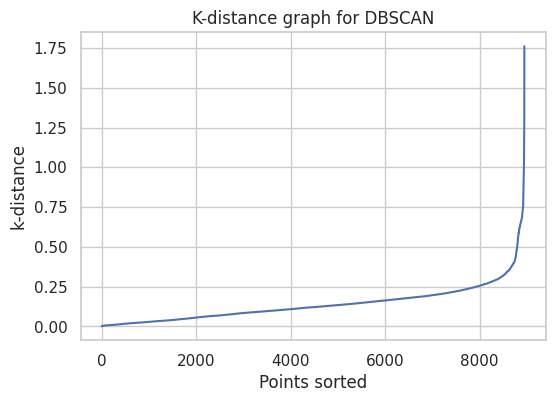

In [17]:
from sklearn.neighbors import NearestNeighbors

k = 3  # same as min_samples
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)

distances, _ = nn.kneighbors(X_scaled)
distances = np.sort(distances[:, k-1])

plt.figure(figsize=(6,4))
plt.plot(distances)
plt.xlabel("Points sorted")
plt.ylabel("k-distance")
plt.title("K-distance graph for DBSCAN")
plt.show()


In [18]:
dbscan = DBSCAN(eps=0.35, min_samples=6)
labels = dbscan.fit_predict(X_scaled)

df['cluster'] = labels
df['cluster'].value_counts()


,count
cluster,
0,8192
1,446
-1,305
2,7


In [21]:
df_dbscan = df.copy()
df_dbscan['cluster'] = labels

df_dbscan.head(10)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,ONEOFF_PURCHASE_RATIO,INSTALLMENT_PURCHASE_RATIO,TOTAL_PURCHASES,PURCHASES_PER_TRX,CASH_ADVANCE_PER_TRX,PAYMENT_RATIO,MINIMUM_PAYMENT_RATIO,FULL_PAYMENT_FLAG,UTILIZATION_RATIO,cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,...,0.000000,1.000000,95.40,47.700000,0.000000,0.201802,0.139510,0,0.095400,0
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,...,0.000000,0.000000,0.00,0.000000,1610.736371,0.586148,0.153191,0,0.920421,0
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,...,1.000000,0.000000,773.17,64.430833,0.000000,0.082942,0.083638,0,0.103089,3
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,...,1.000000,0.000000,1499.00,1499.000000,205.788017,0.000000,0.115228,0,0.227305,8
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,...,1.000000,0.000000,16.00,16.000000,0.000000,0.565279,0.203993,0,0.013333,8
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,...,0.000000,1.000000,1333.28,166.660000,0.000000,0.777810,1.337359,0,0.740711,4
6,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,...,0.902922,0.097078,7091.01,110.797031,0.000000,0.470690,0.014672,1,0.525260,2
7,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,436.20,36.350000,0.000000,0.295246,0.231319,0,0.189652,7
8,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,...,0.767844,0.232156,861.49,172.298000,0.000000,0.098326,0.044566,0,0.123070,8
9,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,...,1.000000,0.000000,1281.60,427.200000,0.000000,0.105888,0.009118,0,0.116509,5


In [22]:
df_dbscan['cluster'].value_counts()
df_dbscan[df_dbscan['cluster'] == -1].head()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,ONEOFF_PURCHASE_RATIO,INSTALLMENT_PURCHASE_RATIO,TOTAL_PURCHASES,PURCHASES_PER_TRX,CASH_ADVANCE_PER_TRX,PAYMENT_RATIO,MINIMUM_PAYMENT_RATIO,FULL_PAYMENT_FLAG,UTILIZATION_RATIO,cluster


In [23]:
df_dbscan['cluster'].value_counts()


,count
cluster,
0,1802
7,1704
8,1281
4,1071
1,807
5,716
3,651
2,480
6,438


Here, using eps (minimum distance between two points) as 2 and minimum samples in a cluster as 6, we get 6 clusters with majority of them being in cluster 0

**Lets try to visualise using two variables like BALANCE and PURCHASES:**

In [24]:
X = df[['BALANCE', 'PURCHASES']].to_numpy()


In [25]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN

# 1. Select features
X = df[['BALANCE', 'PURCHASES']]

# 2. Scale features (MANDATORY for DBSCAN)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply DBSCAN with sensible parameters
dbscan = DBSCAN(eps=2, min_samples=6)
y_dbscan_pred = dbscan.fit_predict(X_scaled)

y_dbscan_pred


array([0, 0, 0, ..., 0, 0, 0])

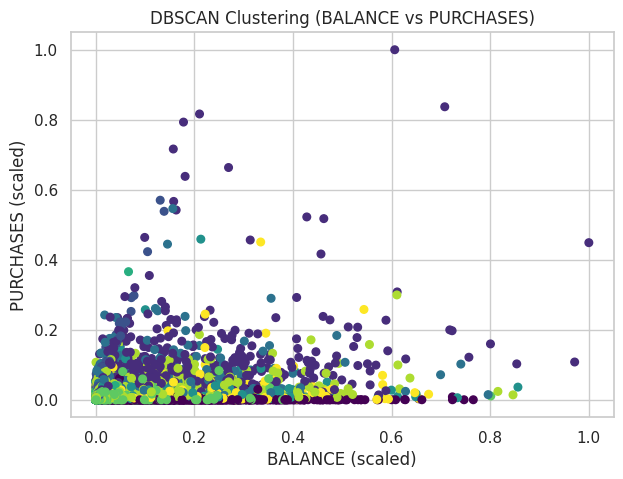

In [26]:
plt.figure(figsize=(7,5))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    cmap='viridis',
    s=30
)
plt.xlabel('BALANCE (scaled)')
plt.ylabel('PURCHASES (scaled)')
plt.title('DBSCAN Clustering (BALANCE vs PURCHASES)')
plt.show()


In [27]:
dbscan = DBSCAN(eps=0.075,min_samples=4)
dbscan.fit(X)
y_dbscan_pred = dbscan.labels_
y_dbscan_pred

array([-1, -1, -1, ..., -1, -1, -1])

In [28]:
df_dbscan['clusters'] = y_dbscan_pred
df_dbscan['clusters'].value_counts()

,count
clusters,
-1,8929
0,16
1,5


Some differences that we observe in K-Means and DBSCAN are:
* Clusters formed using K-Means are more or less spherical or convex in shape and must have same feature size. But using DBSCAN, arbitrary shaped clusters can be formed.
* K-means clustering is more efficient for large datasets and K-means clustering is also sensitive to the number of clusters specified. Whereas in case of DBSCAN, no need to specify the number of clusters manually.
* K-means Clustering does not work well with outliers and noisy datasets whereas DBSCAN works well with outlier.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [32]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.4, min_samples=6)
y_dbscan_pred = dbscan.fit_predict(X_pca)


In [33]:
X = df_dbscan[['BALANCE', 'PURCHASES']]


In [34]:
# Step 1: Create a working DataFrame FIRST
df_work = df[['BALANCE', 'PURCHASES']].copy()

# (If you dropped NaNs earlier, do it here explicitly)
df_work = df_work.dropna()

# Step 2: Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_work)

# Step 3: PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.4, min_samples=6)
y_dbscan_pred = dbscan.fit_predict(X_pca)

# ✅ Step 5: Attach clusters (NOW lengths match)
df_work['cluster_pca'] = y_dbscan_pred

df_work['cluster_pca'].value_counts()


,count
cluster_pca,
0,8823
-1,93
2,18
3,9
1,7


In [35]:
df['cluster_pca'] = y_dbscan_pred
df['cluster_pca'].value_counts()


,count
cluster_pca,
0,8823
-1,93
2,18
3,9
1,7


In [36]:
df.loc[df_work.index, 'cluster_pca'] = y_dbscan_pred


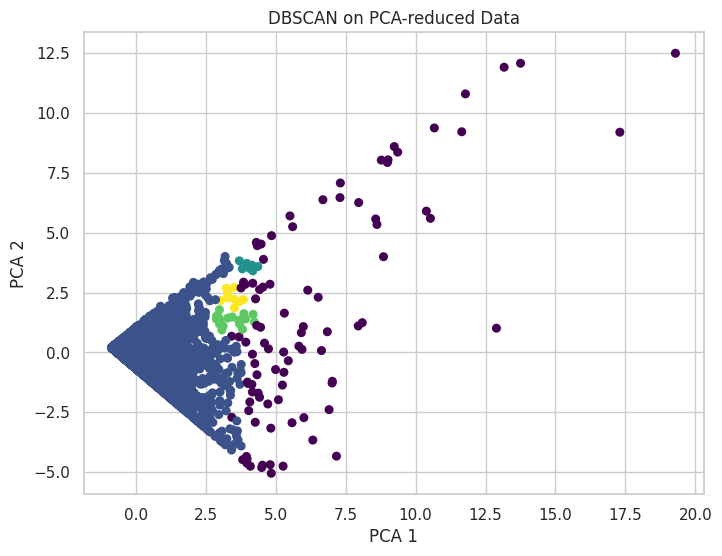

In [37]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_work['cluster_pca'],
    cmap='viridis',
    s=30
)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('DBSCAN on PCA-reduced Data')
plt.show()


In [38]:
df_work.groupby('cluster_pca')[['BALANCE', 'PURCHASES']].mean()


,BALANCE,PURCHASES
cluster_pca,,
-1,8508.119427,12847.545591
0,1483.013824,845.758505
1,2197.910313,12534.602857
2,4541.350361,8168.043333
3,3225.994464,9663.025556


# Task
Modify the code to assign the 2D DBSCAN prediction results (`y_dbscan_pred`) to a new column named 'cluster_2d' in the DataFrame `df` before plotting.

## modify_cells

### Subtask:
Assign the 2D DBSCAN prediction results to a new column in the DataFrame before plotting.


## Summary:

### Data Analysis Key Findings
*   The 2D DBSCAN prediction results, stored in `y_dbscan_pred`, were successfully added to the DataFrame `df` under a new column named 'cluster_2d'.

### Insights or Next Steps
*   This step is crucial for integrating the 2D clustering results directly into the dataset, enabling easier visualization and further analysis alongside other features.
*   The next logical step will involve plotting the data using this new 'cluster_2d' column to visually inspect the 2D clusters identified by DBSCAN.
